In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline

sns.set_theme(style="whitegrid")

In [6]:
df = pd.read_csv('/content/data.csv', encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df.shape

(541909, 8)

In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [10]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [11]:
df.duplicated().sum()

np.int64(5268)

In [12]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [13]:
df = df.dropna(subset=['CustomerID'])

In [14]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [15]:
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [17]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [18]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(8905)

In [19]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [20]:
df = df[df['Quantity'] > 0]

In [21]:
df = df[df['UnitPrice'] > 0]

In [22]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [23]:
df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [24]:
df.shape

(397884, 9)

In [25]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalAmount,0


## Data Cleaning — Observation

Rows without CustomerID were removed because customer identification is
required for customer-level segmentation. Cancelled transactions, invalid
quantities, and invalid unit prices were also removed to ensure that the RFM
analysis is based on valid completed purchases.

A TotalAmount column was created by multiplying Quantity by UnitPrice.

In [26]:
average_purchase_value = df['TotalAmount'].mean()

print("Average Purchase Value:", round(average_purchase_value, 2))

Average Purchase Value: 22.4


In [27]:
purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

purchase_frequency.describe()

,InvoiceNo
count,4338.000000
mean,4.272015
std,7.697998
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,209.000000


In [28]:
customer_lifetime_value = (
    df.groupby('CustomerID')['TotalAmount']
    .sum()
)

customer_lifetime_value.describe()

,TotalAmount
count,4338.000000
mean,2054.266460
std,8989.230441
min,3.750000
25%,307.415000
50%,674.485000
75%,1661.740000
max,280206.020000


In [29]:
print(
    "Average Customer Lifetime Value:",
    round(customer_lifetime_value.mean(), 2)
)

Average Customer Lifetime Value: 2054.27


## Descriptive Statistics — Observation

The average purchase value represents the typical value of a transaction.
Purchase frequency shows how often customers place orders, while historical
customer lifetime value represents the total revenue generated by customers
over the available transaction period.

These measures provide an initial understanding of customer purchasing
behaviour before applying clustering.

In [30]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [31]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [32]:
recency = (
    df.groupby('CustomerID')['InvoiceDate']
    .max()
    .apply(lambda x: (reference_date - x).days)
)

In [33]:
frequency = (
    df.groupby('CustomerID')['InvoiceNo']
    .nunique()
)

In [34]:
monetary = (
    df.groupby('CustomerID')['TotalAmount']
    .sum()
)

In [35]:
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

In [36]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [37]:
rfm.shape

(4338, 3)

In [38]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [39]:
features = ['Recency', 'Frequency', 'Monetary']

rfm_features = rfm[features]

rfm_features.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


## Feature Selection

Recency, Frequency, and Monetary value were selected as the three behavioural
features for customer segmentation.

- Recency measures how recently a customer made a purchase.
- Frequency measures how often a customer makes purchases.
- Monetary measures the total amount spent by a customer.

Together, these RFM features provide a useful representation of customer
purchasing behaviour.

In [40]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

In [41]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=features,
    index=rfm.index
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,2.334574,-0.425097,8.358668
12347,-0.905340,0.354417,0.250966
12348,-0.175360,-0.035340,-0.028596
12349,-0.735345,-0.425097,-0.033012
12350,2.174578,-0.425097,-0.191347


In [42]:
rfm_scaled_df.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,1.801745e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-4.250965e-01,-2.281344e-01
25%,-7.453445e-01,-4.250965e-01,-1.943495e-01
50%,-4.153533e-01,-2.951776e-01,-1.535104e-01
75%,4.946227e-01,9.457903e-02,-4.367134e-02
max,2.814561e+00,2.659803e+01,3.094634e+01


## Data Standardisation

The RFM features have different numerical scales, particularly Monetary
values. StandardScaler was used to standardise the features so that no single
variable dominates the K-Means clustering process because of its larger
numerical magnitude.

In [43]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)

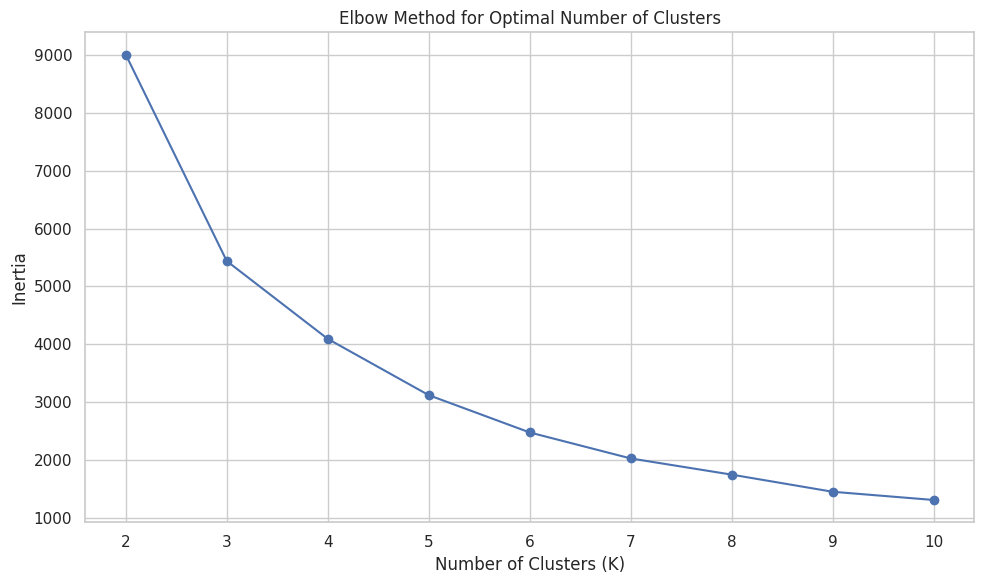

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.xticks(range(2, 11))
plt.tight_layout()

plt.show()

In [45]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,3
12347,2,7,4310.00,0
12348,75,4,1797.24,0
12349,19,1,1757.55,0
12350,310,1,334.40,1


In [46]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

cluster_counts

,count
Cluster,
0,3054
1,1067
2,13
3,204


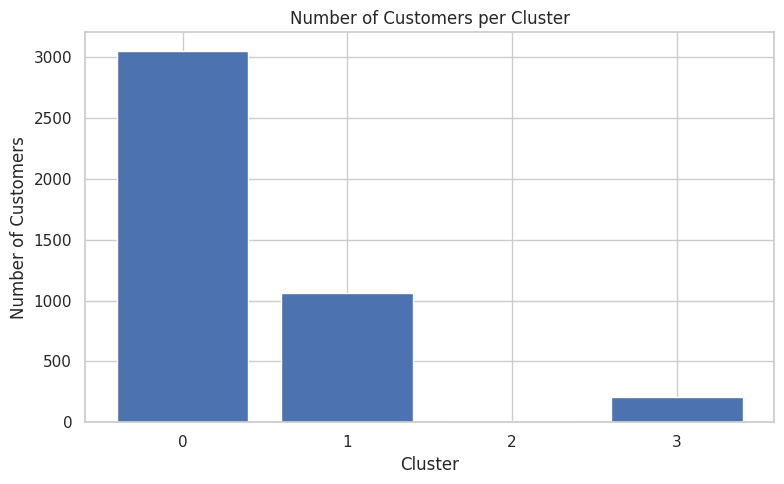

In [47]:
plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [48]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1359.05
1,248.08,1.55,480.62
2,7.38,82.54,127338.31
3,15.50,22.33,12709.09


In [49]:
cluster_names = {
    0: 'Occasional / Low-Value',
    1: 'At-Risk / Inactive',
    2: 'VIP / High-Value',
    3: 'Loyal / Regular'
}

rfm['Customer_Segment'] = rfm['Cluster'].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Customer_Segment
CustomerID,,,,,
12346,326,1,77183.60,3,Loyal / Regular
12347,2,7,4310.00,0,Occasional / Low-Value
12348,75,4,1797.24,0,Occasional / Low-Value
12349,19,1,1757.55,0,Occasional / Low-Value
12350,310,1,334.40,1,At-Risk / Inactive


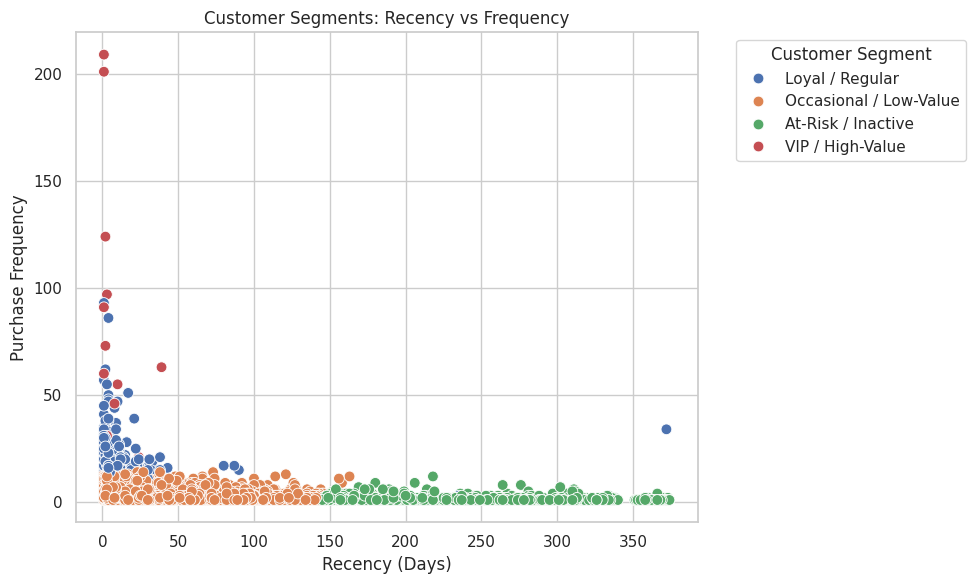

In [50]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Customer_Segment',
    s=60
)

plt.title('Customer Segments: Recency vs Frequency')
plt.xlabel('Recency (Days)')
plt.ylabel('Purchase Frequency')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Recency vs Frequency — Observation

The scatter plot shows clear differences in purchasing behaviour across
the customer segments. VIP / High-Value customers generally have low
recency values and high purchase frequency, indicating that they purchase
frequently and recently.

At-Risk / Inactive customers have much higher recency and low frequency,
indicating limited recent engagement with the business.

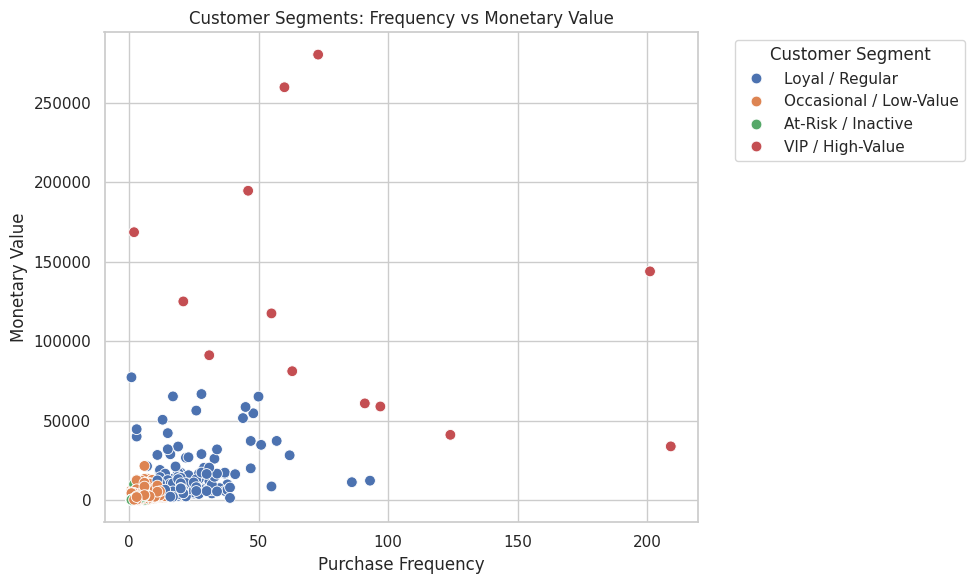

In [51]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Customer_Segment',
    s=60
)

plt.title('Customer Segments: Frequency vs Monetary Value')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Frequency vs Monetary Value — Observation

The relationship between purchase frequency and monetary value shows that
customers with more frequent purchases generally contribute higher total
revenue.

The VIP / High-Value segment stands out with both very high purchase
frequency and monetary value, while the At-Risk / Inactive segment has
low frequency and low monetary contribution.

In [52]:
segment_counts = (
    rfm['Customer_Segment']
    .value_counts()
)

segment_counts

,count
Customer_Segment,
Occasional / Low-Value,3054
At-Risk / Inactive,1067
Loyal / Regular,204
VIP / High-Value,13


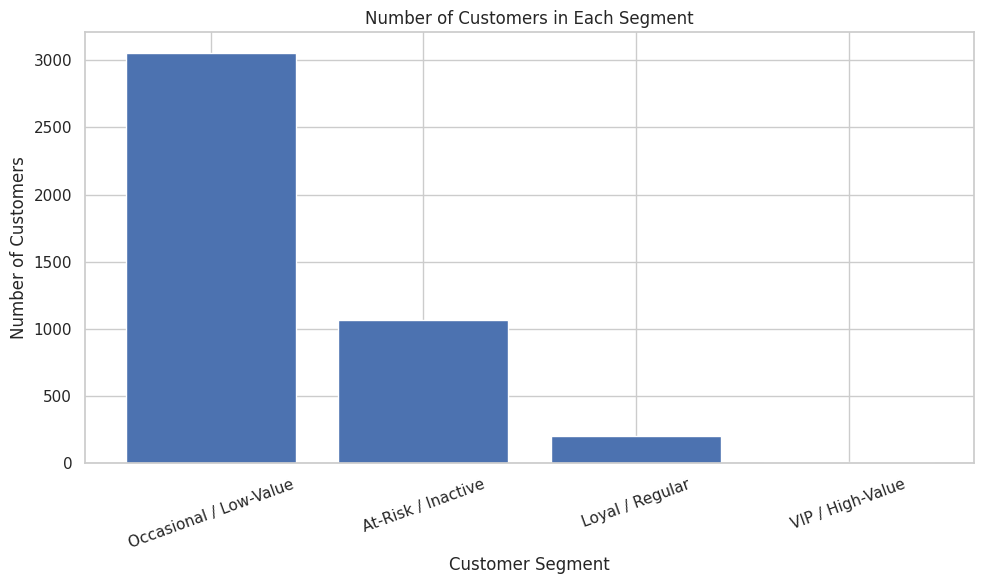

In [53]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title('Number of Customers in Each Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## Customer Segment Distribution — Observation

The customer distribution shows that the four segments have different
population sizes. Understanding the size of each segment helps the business
allocate marketing resources appropriately.

While VIP / High-Value customers may represent a smaller group, their very
high monetary contribution makes them particularly important to retain.

# Marketing Recommendations

### 1. VIP / High-Value Customers

These customers purchase very frequently, recently, and have the highest
monetary contribution.

**Recommended action:**
- Provide loyalty rewards and exclusive benefits.
- Offer early access to new products.
- Provide personalized recommendations.
- Use VIP programs to encourage long-term retention.

### 2. Loyal / Regular Customers

These customers purchase regularly and have relatively recent activity.

**Recommended action:**
- Encourage them to increase their purchase value through cross-selling.
- Provide personalized product recommendations.
- Offer loyalty points and targeted promotions.
- Encourage repeat purchases through member benefits.

### 3. Occasional / Low-Value Customers

These customers purchase less frequently and generate lower monetary value.

**Recommended action:**
- Use targeted discounts to encourage repeat purchases.
- Recommend products based on their previous purchases.
- Introduce bundle offers to increase average order value.

### 4. At-Risk / Inactive Customers

These customers have not purchased recently and have low purchase frequency
and monetary contribution.

**Recommended action:**
- Launch re-engagement campaigns.
- Send personalized offers or limited-time discounts.
- Remind customers about previously purchased products.
- Test targeted incentives to encourage them to return.